C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_26488\2050040878.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='grade', y=actual_weight_col, data=df_grade, palette=sns.color_palette("Set1"), ax=axes[2])
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_26488\2050040878.py:78: UserWarning: The palette list has more values (9) than needed (3), which may not be intended.
  sns.barplot(x='grade', y=actual_weight_col, data=df_grade, palette=sns.color_palette("Set1"), ax=axes[2])
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_26488\2050040878.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='income', y=actual_weight_col, data=df_income, palette=sns.color_pal

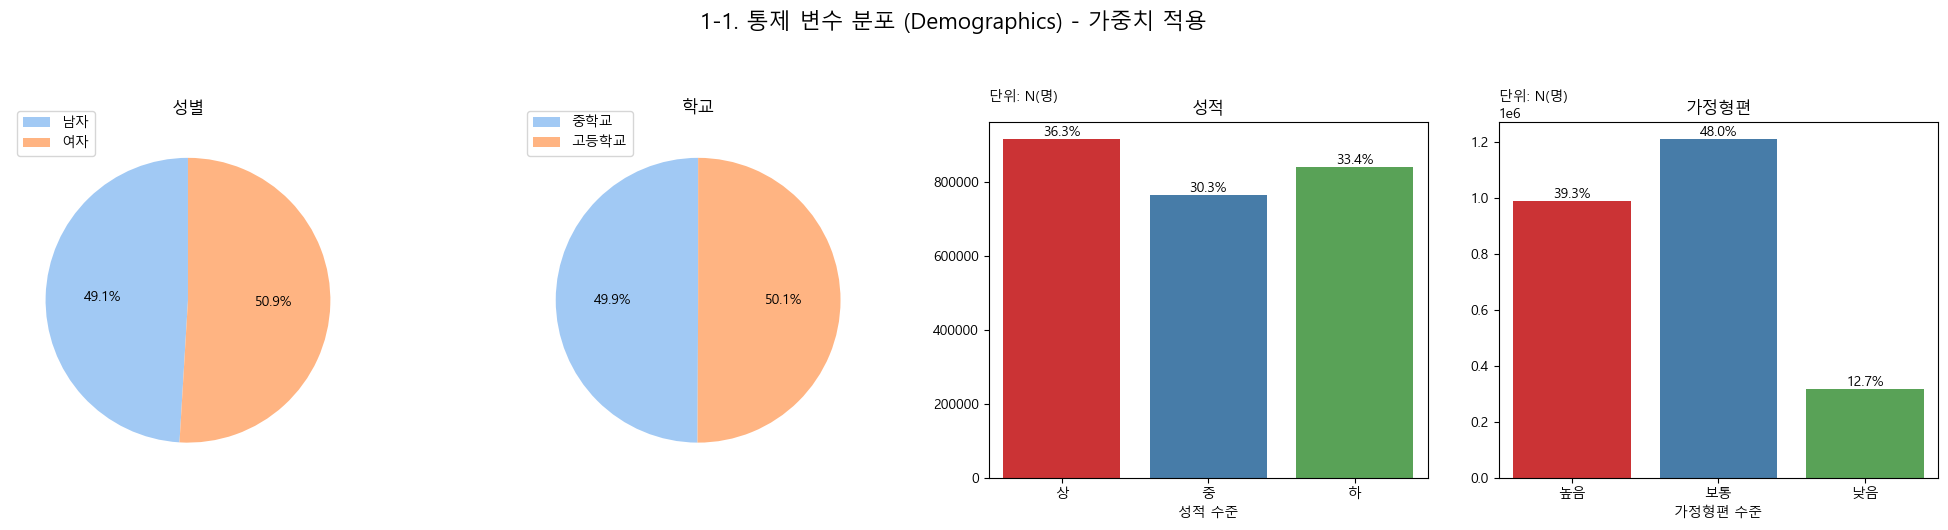

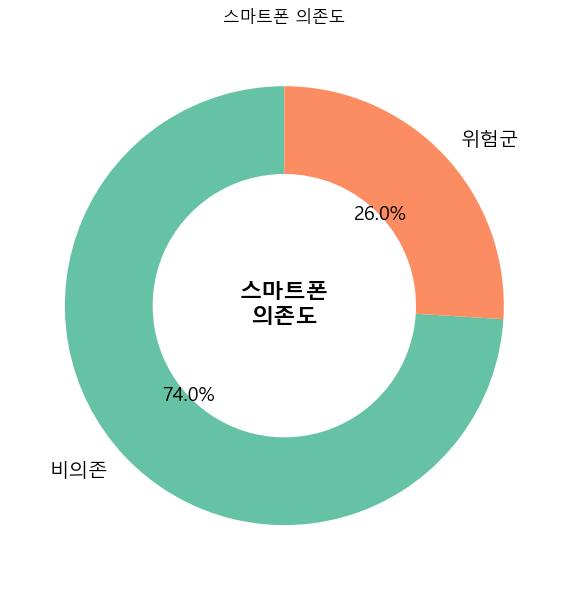

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_26488\2050040878.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=var, y=actual_weight_col, data=df_temp, ax=axes[idx], palette=sns.color_palette("Set2"))
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_26488\2050040878.py:130: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  sns.barplot(x=var, y=actual_weight_col, data=df_temp, ax=axes[idx], palette=sns.color_palette("Set2"))
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_26488\2050040878.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=var, y=actual_weight_col, data=df_temp, ax=axes[idx], palette=sns.color

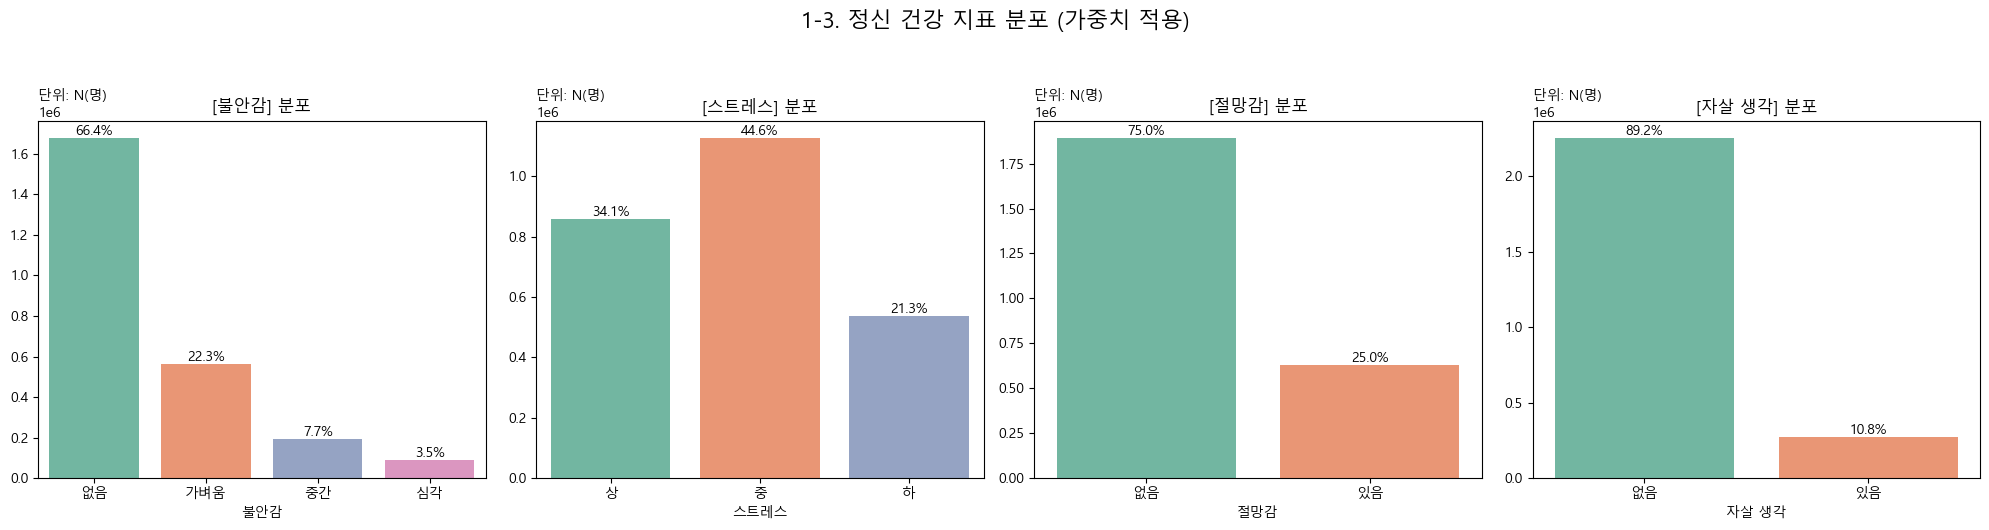

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_26488\2050040878.py:152: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sleep_quality', y=actual_weight_col, data=df_sleep_uni, ax=axes[0], palette=["#357DB8", "#EB2B09"])
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_26488\2050040878.py:165: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='oral_health_label', y=actual_weight_col, data=df_oral_uni, ax=axes[1], palette=["#357DB8", "#EB2B09"])


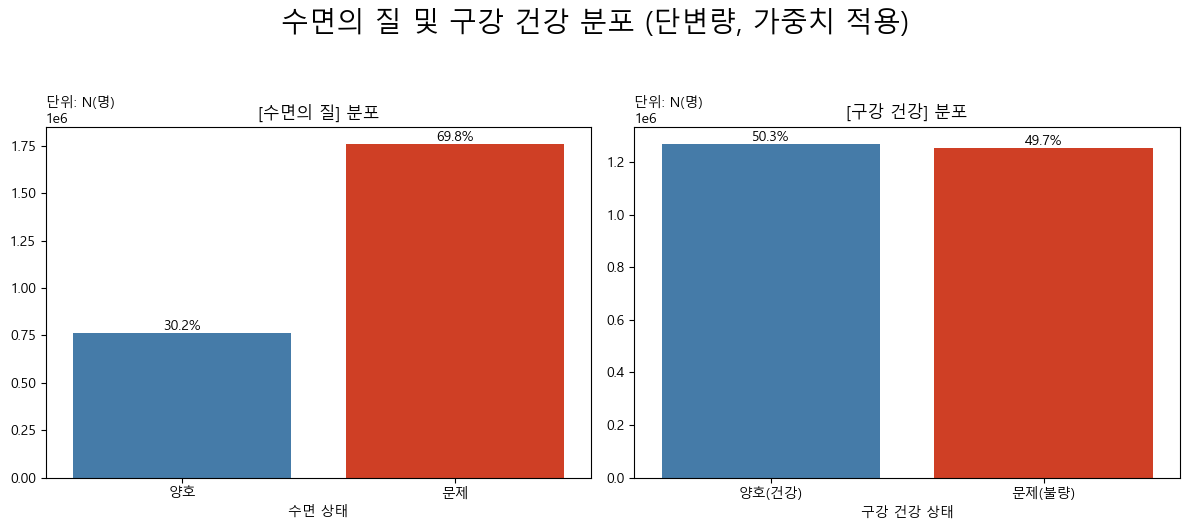

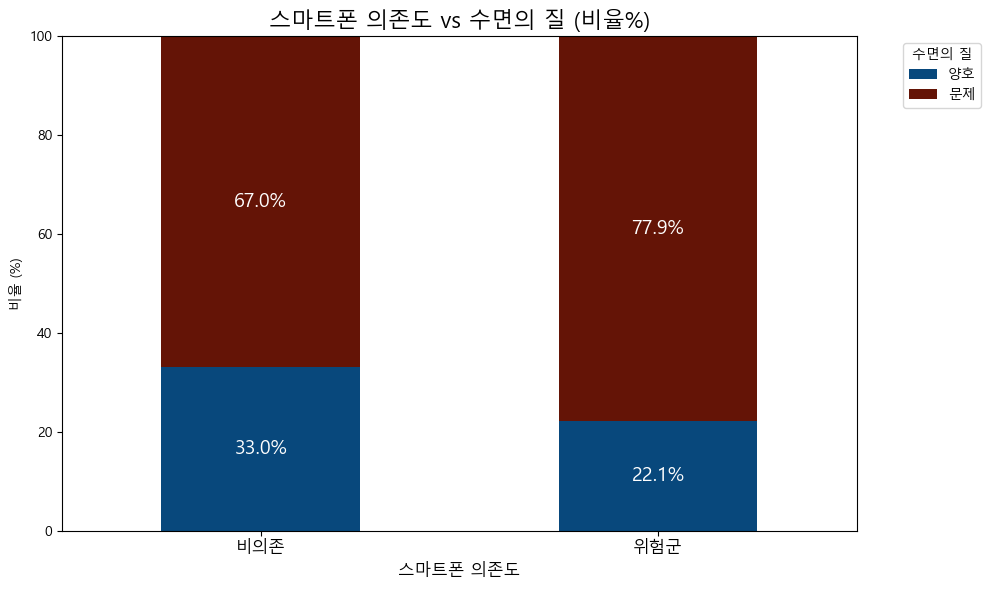

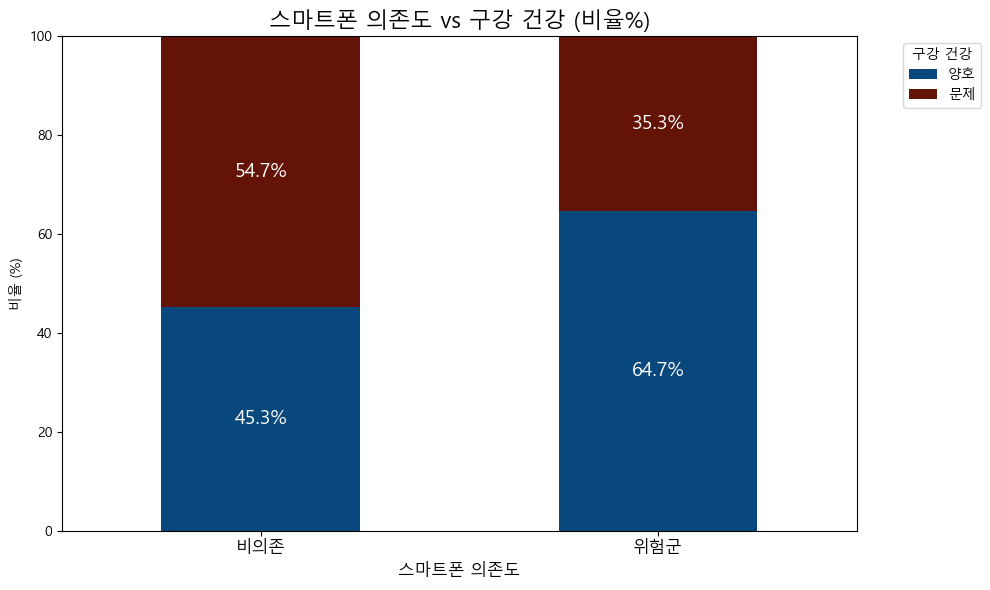

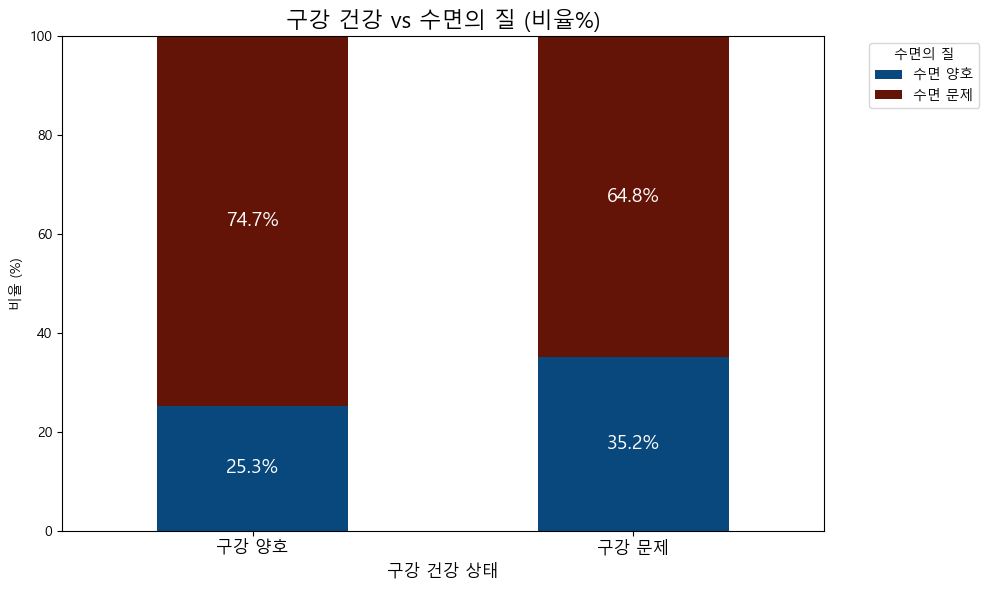

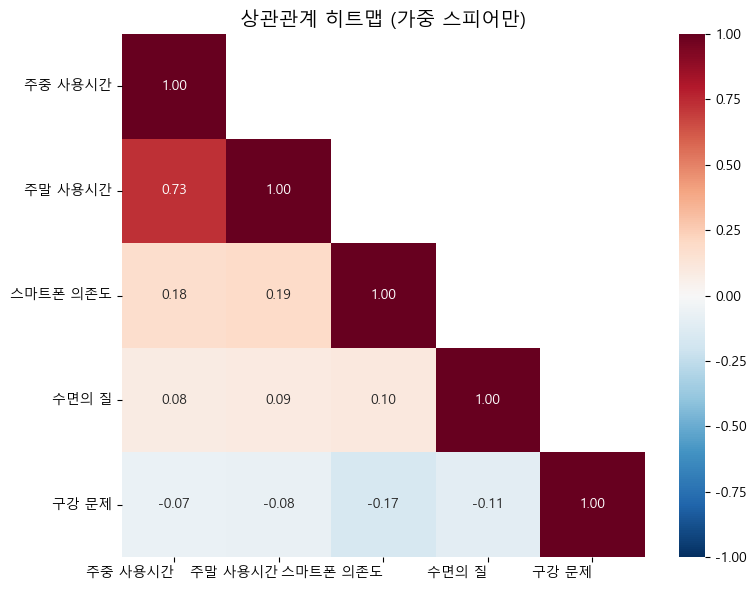

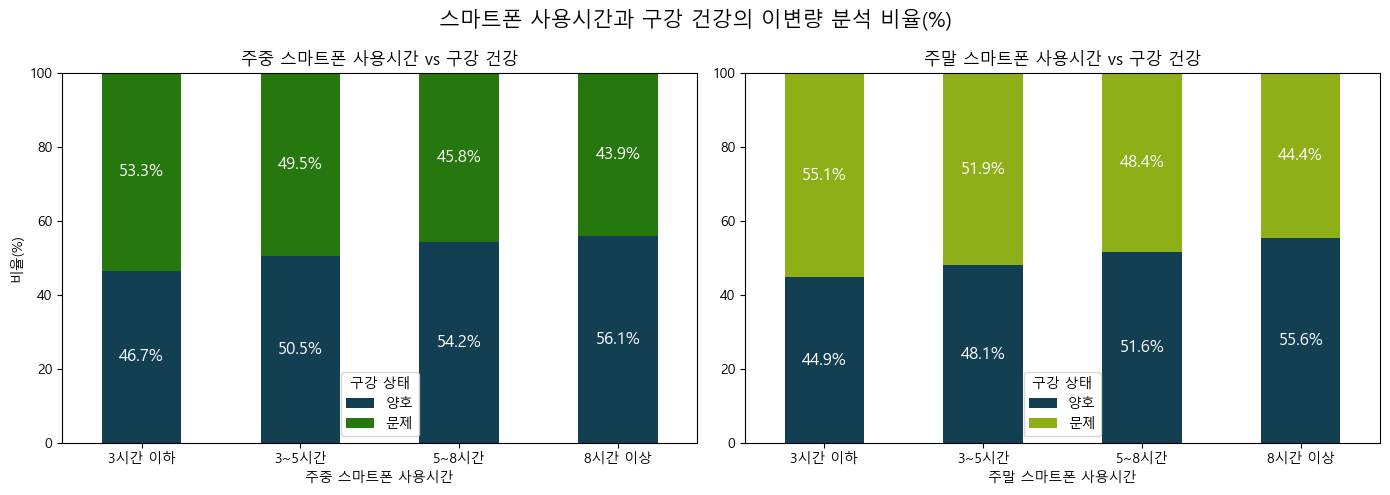

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 0. 환경 및 폴더 설정
# ==========================================
PLOTS_DIR = "./plots"
os.makedirs(PLOTS_DIR, exist_ok=True) # 폴더가 없으면 자동 생성

# 데이터 로드 (경로는 상대경로로 통일)
df_final = pd.read_csv('./data/processed/kyrbs2020_clean_v1.csv', encoding='utf-8-sig')

actual_weight_col = 'W' 
total_weight = df_final[actual_weight_col].sum()

# 그래프 스타일 및 폰트 설정
plt.style.use('default')
sns.set_palette("Set2")
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

grade_income_order = ['High', 'Middle', 'Low']
time_order = ['≤3', '3 ~ 5', '5 ~ 8', '≥8']
anxiety_order = ['No', 'Mild', 'Moderate', 'Severe']

# oral_health(구강 건강) 해석 기준 설정 (Yes=양호, No=문제)
ORAL_GOOD_VAL = 'Yes' 
ORAL_BAD_VAL  = 'No'  

# 헬퍼 함수 정의
def show_pct_on_bar_weighted(ax, tot_weight):
    """막대 그래프 위에 퍼센트를 표시하는 함수"""
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{height/tot_weight*100:.1f}%',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom', fontsize=10)

def add_y_axis_unit(ax, text='단위: N(명)'):
    """y축 좌측 상단에 단위 박스 추가"""
    ax.text(0.0, 1.05, text, transform=ax.transAxes, fontsize=10, ha='left', va='bottom')

def create_weighted_crosstab(index_col, col_col):
    ct = pd.crosstab(
        df_final[index_col],
        df_final[col_col],
        values=df_final[actual_weight_col], 
        aggfunc='sum',
        normalize='index' 
    ) * 100
    return ct

# ==========================================
# 1-1. 통제 변수 (Demographics)
# ==========================================
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('1-1. 통제 변수 분포 (Demographics) - 가중치 적용', fontsize=16, y=1.05)

df_final.groupby('gender')[actual_weight_col].sum().plot.pie(
    labels=['', ''], autopct='%1.1f%%', ax=axes[0], startangle=90, colors=sns.color_palette("pastel")
)
axes[0].set_ylabel('')
axes[0].set_title('성별')
axes[0].legend(['남자', '여자'], loc='upper left', bbox_to_anchor=(0.0, 1.05))

df_final.groupby('school')[actual_weight_col].sum().plot.pie(
    labels=['', ''], autopct='%1.1f%%', ax=axes[1], startangle=90, colors=sns.color_palette("pastel")
)
axes[1].set_ylabel('')
axes[1].set_title('학교')
axes[1].legend(['중학교', '고등학교'], loc='upper left', bbox_to_anchor=(0.0, 1.05))

df_grade = df_final.groupby('grade')[actual_weight_col].sum().reindex(grade_income_order).reset_index()
sns.barplot(x='grade', y=actual_weight_col, data=df_grade, palette=sns.color_palette("Set1"), ax=axes[2])
show_pct_on_bar_weighted(axes[2], total_weight)
axes[2].set_title('성적')
axes[2].set_xlabel('성적 수준')
axes[2].set_ylabel('')
add_y_axis_unit(axes[2])
axes[2].set_xticks(range(len(grade_income_order)))
axes[2].set_xticklabels(['상', '중', '하'], rotation=0)

df_income = df_final.groupby('income')[actual_weight_col].sum().reindex(grade_income_order).reset_index()
sns.barplot(x='income', y=actual_weight_col, data=df_income, palette=sns.color_palette("Set1"), ax=axes[3])
show_pct_on_bar_weighted(axes[3], total_weight)
axes[3].set_title('가정형편')
axes[3].set_xlabel('가정형편 수준')
axes[3].set_ylabel('')
add_y_axis_unit(axes[3])
axes[3].set_xticks(range(len(grade_income_order)))
axes[3].set_xticklabels(['높음', '보통', '낮음'], rotation=0)

plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/EDA_01_demographics.png", dpi=150, bbox_inches='tight')
plt.show()

# ==========================================
# 1-2. 독립 변수 (스마트폰 사용) - 도넛 차트
# ==========================================
plt.figure(figsize=(6,6))
df_final.groupby('smartphone_dependence')[actual_weight_col].sum().plot.pie(
    autopct='%1.1f%%', labels=['비의존', '위험군'], startangle=90, 
    wedgeprops=dict(width=0.4), textprops={'fontsize': 14}
)
plt.text(0, 0, '스마트폰\n의존도', ha='center', va='center', fontsize=16, fontweight='bold')
plt.ylabel('')
plt.title('스마트폰 의존도')
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/EDA_02_smartphone_dependence.png", dpi=150, bbox_inches='tight')
plt.show() 

# ==========================================
# 1-3. 종속 변수 1 (정신 건강)
# ==========================================
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('1-3. 정신 건강 지표 분포 (가중치 적용)', fontsize=16, y=1.05)

mental_vars = [
    ('anxiety', '불안감', anxiety_order, ['없음', '가벼움', '중간', '심각']),
    ('stress', '스트레스', grade_income_order, ['상', '중', '하']),
    ('despair', '절망감', ['No', 'Yes'], ['없음', '있음']),
    ('suicidal_thoughts', '자살 생각', ['No', 'Yes'], ['없음', '있음'])
]
for idx, (var, kor_name, order, labels) in enumerate(mental_vars):
    df_temp = df_final.groupby(var)[actual_weight_col].sum().reindex(order).reset_index()
    sns.barplot(x=var, y=actual_weight_col, data=df_temp, ax=axes[idx], palette=sns.color_palette("Set2"))
    show_pct_on_bar_weighted(axes[idx], total_weight)
    axes[idx].set_title(f'[{kor_name}] 분포')
    axes[idx].set_xlabel(kor_name)
    axes[idx].set_ylabel('')
    add_y_axis_unit(axes[idx])
    axes[idx].set_xticks(range(len(labels)))
    axes[idx].set_xticklabels(labels, rotation=0)

plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/EDA_03_mental_health.png", dpi=150, bbox_inches='tight')
plt.show()

# ==========================================
# 1-4. 종속 변수 2 (수면의 질, 구강 건강)
# ==========================================    
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('수면의 질 및 구강 건강 분포 (단변량, 가중치 적용)', fontsize=20, y=1.05)

# 수면의 질
df_sleep_uni = df_final.groupby('sleep_quality')[actual_weight_col].sum().reset_index()
df_sleep_uni['sleep_quality'] = df_sleep_uni['sleep_quality'].map({'No': '양호', 'Yes': '문제'})
sns.barplot(x='sleep_quality', y=actual_weight_col, data=df_sleep_uni, ax=axes[0], palette=["#357DB8", "#EB2B09"])
show_pct_on_bar_weighted(axes[0], total_weight)
axes[0].set_title('[수면의 질] 분포')
axes[0].set_xlabel('수면 상태')
axes[0].set_ylabel('')
add_y_axis_unit(axes[0])

# 구강 건강
df_oral_uni = df_final.groupby('oral_health')[actual_weight_col].sum().reset_index()
df_oral_uni['oral_health_label'] = df_oral_uni['oral_health'].map({ORAL_GOOD_VAL: '양호(건강)', ORAL_BAD_VAL: '문제(불량)'})
df_oral_uni['oral_health_label'] = pd.Categorical(df_oral_uni['oral_health_label'], categories=['양호(건강)', '문제(불량)'], ordered=True)
df_oral_uni = df_oral_uni.sort_values('oral_health_label')

sns.barplot(x='oral_health_label', y=actual_weight_col, data=df_oral_uni, ax=axes[1], palette=["#357DB8", "#EB2B09"])
show_pct_on_bar_weighted(axes[1], total_weight)
axes[1].set_title('[구강 건강] 분포')
axes[1].set_xlabel('구강 건강 상태')
axes[1].set_ylabel('')
add_y_axis_unit(axes[1])

plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/EDA_04_sleep_oral_health.png", dpi=150, bbox_inches='tight')
plt.show()

# ==========================================
# Crosstab 막대 그래프들
# ==========================================
# 1) 수면의 질 교차표
ct_sleep_dep = create_weighted_crosstab('smartphone_dependence', 'sleep_quality')[['No', 'Yes']]
ct_sleep_dep.columns = ['양호', '문제']   
ax_sleep_dep = ct_sleep_dep.plot(kind='bar', stacked=True, figsize=(10, 6), color=["#08487C", "#641406"])
for c in ax_sleep_dep.containers:
    ax_sleep_dep.bar_label(c, fmt='%.1f%%', label_type='center', fontsize=14, color='white')

ax_sleep_dep.set_ylim(0, 100) 
ax_sleep_dep.set_xticklabels(['비의존', '위험군'], fontsize=12, rotation=0)
plt.title('스마트폰 의존도 vs 수면의 질 (비율%)', fontsize=16)
plt.ylabel('비율 (%)')
plt.xlabel('스마트폰 의존도', fontsize=12)
plt.legend(title='수면의 질', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/EDA_05_crosstab_sleep_dep.png", dpi=150, bbox_inches='tight')
plt.show()

# 2) 구강건강 교차표
ct_oral_dep = create_weighted_crosstab('smartphone_dependence', 'oral_health')[[ORAL_GOOD_VAL, ORAL_BAD_VAL]]
ct_oral_dep.columns = ['양호', '문제']

ax_oral_dep = ct_oral_dep.plot(kind='bar', stacked=True, figsize=(10, 6), color=["#08487C", "#641406"])
for c in ax_oral_dep.containers:
    ax_oral_dep.bar_label(c, fmt='%.1f%%', label_type='center', fontsize=14, color='white')

ax_oral_dep.set_ylim(0, 100)
ax_oral_dep.set_xticklabels(['비의존', '위험군'], fontsize=12, rotation=0)
plt.title('스마트폰 의존도 vs 구강 건강 (비율%)', fontsize=16)
plt.ylabel('비율 (%)')
plt.xlabel('스마트폰 의존도', fontsize=12)
plt.legend(title='구강 건강', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/EDA_06_crosstab_oral_dep.png", dpi=150, bbox_inches='tight')
plt.show()

# 3) 구강건강 vs 수면의 질 교차표
ct_sleep_oral = create_weighted_crosstab('oral_health', 'sleep_quality')[['No', 'Yes']]
ct_sleep_oral = ct_sleep_oral.reindex([ORAL_GOOD_VAL, ORAL_BAD_VAL])
ct_sleep_oral.index = ['구강 양호', '구강 문제']
ct_sleep_oral.columns = ['수면 양호', '수면 문제']

ax_sleep_oral = ct_sleep_oral.plot(kind='bar', stacked=True, figsize=(10, 6), color=["#08487C", "#641406"])
for c in ax_sleep_oral.containers:
    ax_sleep_oral.bar_label(c, fmt='%.1f%%', label_type='center', fontsize=14, color='white')

ax_sleep_oral.set_ylim(0, 100)
ax_sleep_oral.set_xticklabels(['구강 양호', '구강 문제'], fontsize=12, rotation=0)
plt.ylabel('비율 (%)')
plt.title('구강 건강 vs 수면의 질 (비율%)', fontsize=16)
plt.xlabel('구강 건강 상태', fontsize=12)
plt.legend(title='수면의 질', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/EDA_07_crosstab_sleep_oral.png", dpi=150, bbox_inches='tight')
plt.show()

# ==========================================
# 상관관계 히트맵
# ==========================================
use_map = {'≤3': 0, '3 ~ 5': 1, '5 ~ 8': 2, '≥8': 3}
dep_map = {'No': 0, 'Risk': 1}
sleep_map = {'No': 0, 'Yes': 1}
oral_map = {ORAL_GOOD_VAL: 0, ORAL_BAD_VAL: 1} 

df_heat = df_final[['smartphone_use_day', 'smartphone_use_weekend', 'smartphone_dependence', 'sleep_quality', 'oral_health', actual_weight_col]].copy()

df_heat['주중 사용시간'] = df_heat['smartphone_use_day'].map(use_map)
df_heat['주말 사용시간'] = df_heat['smartphone_use_weekend'].map(use_map)
df_heat['스마트폰 의존도'] = df_heat['smartphone_dependence'].map(dep_map)
df_heat['수면의 질'] = df_heat['sleep_quality'].map(sleep_map)
df_heat['구강 문제'] = df_heat['oral_health'].map(oral_map)

corr_cols = ['주중 사용시간', '주말 사용시간', '스마트폰 의존도', '수면의 질', '구강 문제']
df_corr_data = df_heat[corr_cols + [actual_weight_col]].dropna()

ranked_data = df_corr_data[corr_cols].rank()
weights = df_corr_data[actual_weight_col].values

cov_matrix = np.cov(ranked_data.values.T, aweights=weights)
std_devs = np.sqrt(np.diag(cov_matrix))
weighted_spearman_corr = cov_matrix / np.outer(std_devs, std_devs)

weighted_corr_df = pd.DataFrame(weighted_spearman_corr, index=corr_cols, columns=corr_cols)

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(weighted_corr_df, dtype=bool), k=1)
ax = sns.heatmap(
    weighted_corr_df, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    vmin=-1, vmax=1, center=0, square=True
)
plt.title('상관관계 히트맵 (가중 스피어만)', fontsize=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='right')

plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/EDA_08_correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

# -------------------------
# 주중/주말 스마트폰 사용시간 vs 구강 건강
# -------------------------
ct_oral_day = create_weighted_crosstab('smartphone_use_day', 'oral_health').reindex(time_order)[[ORAL_GOOD_VAL, ORAL_BAD_VAL]]
ct_oral_day.columns = ['양호', '문제']

ct_oral_weekend = create_weighted_crosstab('smartphone_use_weekend', 'oral_health').reindex(time_order)[[ORAL_GOOD_VAL, ORAL_BAD_VAL]]
ct_oral_weekend.columns = ['양호', '문제']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ct_oral_day.plot(kind='bar', stacked=True, ax=axes[0], color=["#133F52", "#27770F"])
for c in axes[0].containers:
    axes[0].bar_label(c, fmt='%.1f%%', label_type='center', fontsize=12, color='white')
axes[0].set_ylim(0, 100)
axes[0].set_title('주중 스마트폰 사용시간 vs 구강 건강')
axes[0].set_xlabel('주중 스마트폰 사용시간')
axes[0].set_ylabel('비율(%)')
axes[0].set_xticklabels(['3시간 이하', '3~5시간', '5~8시간', '8시간 이상'], rotation=0)
axes[0].legend(title='구강 상태')

ct_oral_weekend.plot(kind='bar', stacked=True, ax=axes[1], color=["#133F52", "#8EAF17"])
for c in axes[1].containers:
    axes[1].bar_label(c, fmt='%.1f%%', label_type='center', fontsize=12, color='white')
axes[1].set_ylim(0, 100)
axes[1].set_title('주말 스마트폰 사용시간 vs 구강 건강')
axes[1].set_xlabel('주말 스마트폰 사용시간')
axes[1].set_ylabel('')
axes[1].set_xticklabels(['3시간 이하', '3~5시간', '5~8시간', '8시간 이상'], rotation=0)
axes[1].legend(title='구강 상태')

fig.suptitle('스마트폰 사용시간과 구강 건강의 이변량 분석 비율(%)', fontsize=15)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/EDA_09_crosstab_smartphone_time_oral.png", dpi=150, bbox_inches='tight')
plt.show()